# Demand Pattern Evaluation

This notebook evaluates forecasting performance across different demand patterns: Regular, Irregular, and Intermittent.

The analysis connects the demand pattern classification from the data preparation stage with the forecasting results produced by Seasonal Naive, XGBoost, and LightGBM models.

The main objective is to identify which forecasting model performs best for each demand pattern, with particular focus on Intermittent demand.

## 1. Setup and Data Loading

This section loads the required libraries and the model evaluation outputs generated during the forecasting stage.

In [1]:
import pandas as pd
import numpy as np

from sklearn.metrics import (
    mean_squared_log_error,
    mean_absolute_error,
    mean_squared_error
)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
comparison_df = pd.read_csv(
    "../outputs/forecasts/model_comparison_results.csv"
)

pattern_results_df = pd.read_csv(
    "../outputs/forecasts/error_analysis_by_pattern.csv"
)

print("Model comparison results:")
display(comparison_df)

print("\nPattern-level results:")
display(pattern_results_df)

Model comparison results:


,Model,RMSLE,MAE,RMSE,WMAPE
0,Seasonal Naive,0.577850,104.416304,359.286170,21.767878
1,XGBoost,0.480255,75.225977,244.051642,15.682512
2,LightGBM,0.554266,73.397247,235.695448,15.301273



Pattern-level results:


,Pattern,Seasonal Naive MAE,XGBoost MAE,LightGBM MAE
0,Regular,150.261575,107.631327,104.545618
1,Intermittent,0.978378,1.259221,1.874321
2,Irregular,28.357453,21.965092,22.452079


## 2. Loading Detailed Predictions

The summary files loaded above (model_comparison_results.csv, 
error_analysis_by_pattern.csv) only contain MAE broken down by pattern, 
while the project's primary metric is RMSLE. This section loads the 
row-level predictions (actual vs. predicted per model, per row) needed 
to compute RMSLE, MAE, and RMSE for each demand pattern separately.

In [3]:
predictions_df = pd.read_parquet("../data/processed/predictions_detailed.parquet")

print(predictions_df.shape)
print(predictions_df["pattern"].value_counts())
predictions_df.head()

(25920, 8)
pattern
Regular         16920
Irregular        5670
Intermittent     3330
Name: count, dtype: int64


,date,store_nbr,family,pattern,sales,seasonal_naive_pred,xgboost_pred,lightgbm_pred
0,2017-08-01,1,AUTOMOTIVE,Regular,5.0,10.0,5.737589,7.328789
1,2017-08-02,1,AUTOMOTIVE,Regular,4.0,2.0,4.313277,5.265268
2,2017-08-03,1,AUTOMOTIVE,Regular,3.0,5.0,4.317686,5.707660
3,2017-08-04,1,AUTOMOTIVE,Regular,8.0,7.0,4.472504,5.772361
4,2017-08-05,1,AUTOMOTIVE,Regular,5.0,4.0,6.545494,8.501983


## 3. Validation Checks

Before calculating demand-pattern performance metrics, the detailed prediction data is validated to ensure that the evaluation is based on complete and consistent observations.

The checks include missing values, duplicated observations, and non-negative values required for RMSLE.

In [4]:
print("Missing values:")
print(predictions_df.isna().sum())

print("\nDuplicate rows:", predictions_df.duplicated().sum())

Missing values:
date                   0
store_nbr              0
family                 0
pattern                0
sales                  0
seasonal_naive_pred    0
xgboost_pred           0
lightgbm_pred          0
dtype: int64

Duplicate rows: 0


In [5]:
print("Negative actual sales:", (predictions_df["sales"] < 0).sum())

print("\nNegative predictions:")
print((predictions_df[
    ["seasonal_naive_pred", "xgboost_pred", "lightgbm_pred"]
] < 0).sum())

Negative actual sales: 0

Negative predictions:
seasonal_naive_pred    0
xgboost_pred           0
lightgbm_pred          0
dtype: int64


### Insight

The validation checks confirm that the detailed prediction dataset contains no missing values, duplicate rows, or negative actual and predicted values. Therefore, the data is suitable for calculating RMSLE and other evaluation metrics by demand pattern.

## 4. Performance by Demand Pattern

This section calculates RMSLE, MAE, and RMSE for each forecasting model across Regular, Irregular, and Intermittent demand patterns.

In [6]:
models = {
    "Seasonal Naive": "seasonal_naive_pred",
    "XGBoost": "xgboost_pred",
    "LightGBM": "lightgbm_pred"
}

results = []

for pattern in predictions_df["pattern"].unique():
    pattern_df = predictions_df[predictions_df["pattern"] == pattern]

    for model, pred_col in models.items():
        actual = pattern_df["sales"]
        predicted = pattern_df[pred_col]

        rmsle = np.sqrt(mean_squared_log_error(actual, predicted))
        mae = mean_absolute_error(actual, predicted)
        rmse = np.sqrt(mean_squared_error(actual, predicted))

        results.append({
            "Pattern": pattern,
            "Model": model,
            "RMSLE": rmsle,
            "MAE": mae,
            "RMSE": rmse
        })

pattern_metrics = pd.DataFrame(results)

pattern_metrics

,Pattern,Model,RMSLE,MAE,RMSE
0,Regular,Seasonal Naive,0.497470,150.261575,441.915664
1,Regular,XGBoost,0.395508,107.631327,299.708666
2,Regular,LightGBM,0.424042,104.545618,289.126743
3,Intermittent,Seasonal Naive,0.595971,0.978378,3.903029
4,Intermittent,XGBoost,0.654809,1.259221,4.327919
5,Intermittent,LightGBM,0.861337,1.874321,7.281960
6,Irregular,Seasonal Naive,0.761148,28.357453,85.629868
7,Irregular,XGBoost,0.579450,21.965092,64.951789
8,Irregular,LightGBM,0.657336,22.452079,66.831893


### Insight

The results show that model performance varies across demand patterns.

For Regular demand, XGBoost achieves the lowest RMSLE, while LightGBM achieves the lowest MAE and RMSE.

For Irregular demand, XGBoost performs best across all three metrics.

For Intermittent demand, Seasonal Naive performs best across all three metrics, outperforming both machine learning models.

## 5. Best Model by Demand Pattern

This section identifies the best-performing model for each demand pattern based on RMSLE, the primary evaluation metric.

In [7]:
best_models = pattern_metrics.loc[
    pattern_metrics.groupby("Pattern")["RMSLE"].idxmin()
]

best_models

,Pattern,Model,RMSLE,MAE,RMSE
3,Intermittent,Seasonal Naive,0.595971,0.978378,3.903029
7,Irregular,XGBoost,0.579450,21.965092,64.951789
1,Regular,XGBoost,0.395508,107.631327,299.708666


### Insight

XGBoost performs best for Regular and Irregular demand based on RMSLE.

For Intermittent demand, Seasonal Naive performs best, showing that the simpler baseline is more effective than the machine learning models for sparse demand.

## 6. Intermittent Demand Analysis

This section focuses on forecasting performance for Intermittent demand, where sales are sparse and occur irregularly.

In [8]:
intermittent_results = pattern_metrics[
    pattern_metrics["Pattern"] == "Intermittent"
].sort_values("RMSLE")

intermittent_results

,Pattern,Model,RMSLE,MAE,RMSE
3,Intermittent,Seasonal Naive,0.595971,0.978378,3.903029
4,Intermittent,XGBoost,0.654809,1.259221,4.327919
5,Intermittent,LightGBM,0.861337,1.874321,7.281960


### Insight

Seasonal Naive achieves the best performance for Intermittent demand across RMSLE, MAE, and RMSE. Both XGBoost and LightGBM perform worse, with LightGBM showing the highest errors.

## 7. Model Performance Comparison

This section visualizes RMSLE across demand patterns to compare model performance.

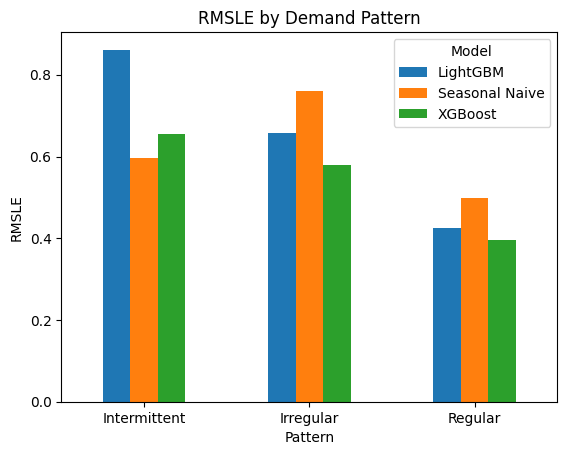

In [9]:
import matplotlib.pyplot as plt

pattern_metrics.pivot(
    index="Pattern",
    columns="Model",
    values="RMSLE"
).plot(kind="bar")

plt.ylabel("RMSLE")
plt.title("RMSLE by Demand Pattern")
plt.xticks(rotation=0)
plt.show()

### Insight

The RMSLE comparison shows that XGBoost performs best for Regular and Irregular demand, while Seasonal Naive performs best for Intermittent demand.

## 8. Error Analysis

This section compares forecasting errors across demand patterns using MAE.

In [10]:
error_comparison = pattern_metrics.pivot(
    index="Pattern",
    columns="Model",
    values="MAE"
)

error_comparison

Model,LightGBM,Seasonal Naive,XGBoost
Pattern,,,
Intermittent,1.874321,0.978378,1.259221
Irregular,22.452079,28.357453,21.965092
Regular,104.545618,150.261575,107.631327


### Insight

Intermittent demand has the lowest absolute MAE, but it remains challenging based on RMSLE. This is expected because intermittent demand contains many zero or low-sales observations, making relative forecasting errors more important.

## 9. Intermittent Error by Family

This section compares model performance across the product families classified as Intermittent.

In [11]:
intermittent_df = predictions_df[
    predictions_df["pattern"] == "Intermittent"
]

family_results = []

for family in intermittent_df["family"].unique():
    family_df = intermittent_df[intermittent_df["family"] == family]

    for model, pred_col in models.items():
        actual = family_df["sales"]
        predicted = family_df[pred_col]

        rmsle = np.sqrt(mean_squared_log_error(actual, predicted))
        mae = mean_absolute_error(actual, predicted)
        rmse = np.sqrt(mean_squared_error(actual, predicted))

        family_results.append({
            "Family": family,
            "Model": model,
            "RMSLE": rmsle,
            "MAE": mae,
            "RMSE": rmse
        })

family_metrics = pd.DataFrame(family_results)

family_metrics.sort_values("RMSLE")

,Family,Model,RMSLE,MAE,RMSE
0,BOOKS,Seasonal Naive,0.168034,0.057143,0.251976
3,HOME APPLIANCES,Seasonal Naive,0.384571,0.285926,0.678779
9,BABY CARE,Seasonal Naive,0.423253,0.341667,0.784219
15,LAWN AND GARDEN,Seasonal Naive,0.545811,1.388889,3.257470
16,LAWN AND GARDEN,XGBoost,0.560568,1.313391,2.722581
29,BEAUTY,LightGBM,0.569459,0.846197,1.314019
12,HARDWARE,Seasonal Naive,0.600196,0.803704,1.169045
25,LADIESWEAR,XGBoost,0.601188,1.236339,2.304987
4,HOME APPLIANCES,XGBoost,0.602482,0.674519,1.128644
28,BEAUTY,XGBoost,0.604109,0.836578,1.371484


### Best Model by Intermittent Family

The best-performing model is identified for each Intermittent product family based on RMSLE.

In [12]:
best_family_models = family_metrics.loc[
    family_metrics.groupby("Family")["RMSLE"].idxmin()
]

best_family_models.sort_values("RMSLE")


,Family,Model,RMSLE,MAE,RMSE
0,BOOKS,Seasonal Naive,0.168034,0.057143,0.251976
3,HOME APPLIANCES,Seasonal Naive,0.384571,0.285926,0.678779
9,BABY CARE,Seasonal Naive,0.423253,0.341667,0.784219
15,LAWN AND GARDEN,Seasonal Naive,0.545811,1.388889,3.257470
29,BEAUTY,LightGBM,0.569459,0.846197,1.314019
12,HARDWARE,Seasonal Naive,0.600196,0.803704,1.169045
25,LADIESWEAR,XGBoost,0.601188,1.236339,2.304987
20,MAGAZINES,LightGBM,0.633348,1.071245,1.506035
32,PLAYERS AND ELECTRONICS,LightGBM,0.684012,1.140555,1.612799
21,PET SUPPLIES,Seasonal Naive,0.704333,1.328205,1.893308


In [13]:
best_family_models["Model"].value_counts()

Model
Seasonal Naive    7
LightGBM          3
XGBoost           2
Name: count, dtype: int64

### Insight

Seasonal Naive achieves the best RMSLE in 7 of the 12 Intermittent product families, while LightGBM is best in 3 families and XGBoost in 2 families. This supports the overall finding that the simpler Seasonal Naive model performs strongly for Intermittent demand.

## 10. Final Findings

This section summarizes the main findings from the demand-pattern evaluation.

In [14]:
final_results = pattern_metrics.pivot(
    index="Pattern",
    columns="Model",
    values="RMSLE"
)

final_results

Model,LightGBM,Seasonal Naive,XGBoost
Pattern,,,
Intermittent,0.861337,0.595971,0.654809
Irregular,0.657336,0.761148,0.579450
Regular,0.424042,0.497470,0.395508


### Key Findings

- XGBoost performs best for Regular demand based on RMSLE.
- XGBoost performs best for Irregular demand based on RMSLE.
- Seasonal Naive performs best for Intermittent demand based on RMSLE.
- Seasonal Naive achieves the best RMSLE in 7 of the 12 Intermittent families.
- The results show that model performance depends on the underlying demand pattern.

## 11. Conclusion

The evaluation shows that no single forecasting model performs best across all demand patterns. XGBoost is the strongest model for Regular and Irregular demand, while Seasonal Naive performs best for Intermittent demand.

For Intermittent demand, the simpler Seasonal Naive model outperforms both XGBoost and LightGBM overall and achieves the best RMSLE in most Intermittent product families.

These results highlight the importance of considering demand patterns when selecting forecasting models.